## Import Libraries

In [1]:
import numpy as np 
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import glob
import seaborn as sns
# sns.set_style("darkgrid")
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from num2words import num2words
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
%matplotlib inline

## Making Nside 128 HEALPix maps of different parameters

### Nside 128 pop dens HEALPix map using GTiff file

In [2]:
##---------Read the tif file---------##
image = tiff.imread('./gpw_v4_population_density_adjusted_to_2015_unwpp_country_totals_rev11_2020_15_min.tif')
image_array = np.array(image)


#----------Define the spherical coordinates----------#
theta = np.linspace(np.radians(0), np.radians(180), num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.radians(180), np.radians(180), num=image_array.shape[1],endpoint=False)

#---------- Set angular resolution----------#
nside = 128

##--------Make empty healpix mask and pixel values vector--------##
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)


for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1

#--------Average value of each pixel--------#
healpix_map[pixel_counts>0] /= pixel_counts[pixel_counts>0 ]




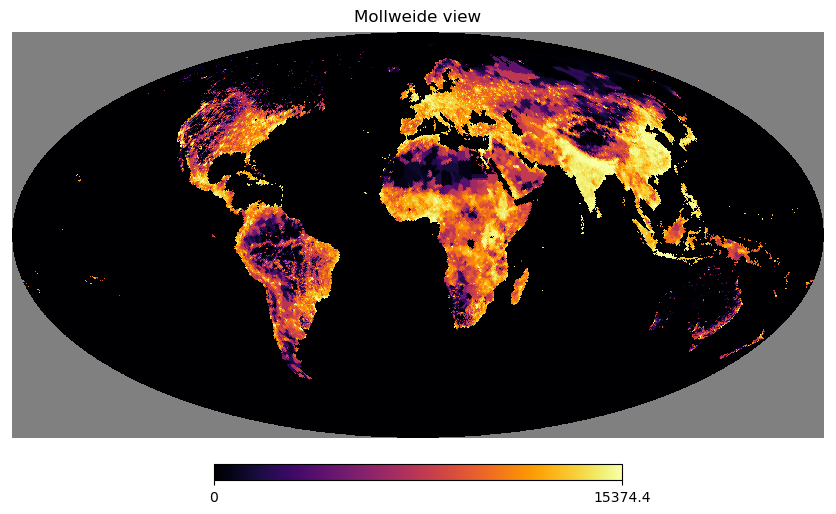

In [3]:
hp.mollview(healpix_map, cmap="inferno", xsize=3000, flip="geo", norm="hist", min=0)
plt.show()

In [4]:
#GEOTiff maps are georeferenced meaning the pixels of the image
#correspond to an affine transformation of WGS84 in this case
#hence we can confirm that the right data points from the original image go into the
#right HEALPix pixel if we make sure our defined sph coords match the shape of the image

### Reading STARFIRE Tx database

In [5]:
csv_files = glob.glob('./database/*.csv')





# --Create an empty dataframe to store the combined data-- #
combined_df = pd.DataFrame()

# Loop through each CSV file and append its contents to the combined dataframe
for csv_file in (csv_files):
    df_temp = pd.read_csv(csv_file)
    combined_df = pd.concat([combined_df, df_temp])
# combined_df=combined_df.dropna().reset_index(drop=True)


lat_128=combined_df['Latitude in degrees'].to_numpy()
lon_128=combined_df['Longitude in degrees'].to_numpy()
# Remove NaN values from lat_128
lat_128 = lat_128[~np.isnan(lat_128)]

# Remove NaN values from lon_128
lon_128 = lon_128[~np.isnan(lon_128)]

power_128=combined_df['EIRP'].to_numpy()
pixel_128=hp.ang2pix(128,lon_128,lat_128,lonlat=True)

### Num of Tx map

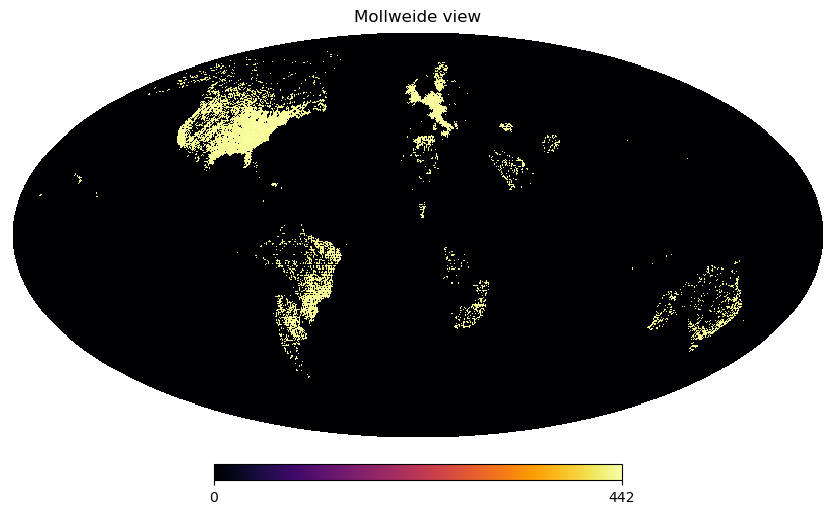

In [6]:
Tx_num_128=np.zeros(hp.nside2npix(128))
for pix in pixel_128:
    Tx_num_128[pix]+=1
hp.mollview(Tx_num_128,flip='geo',min=0,cmap='inferno',norm='hist')
plt.show()

### Tx power map

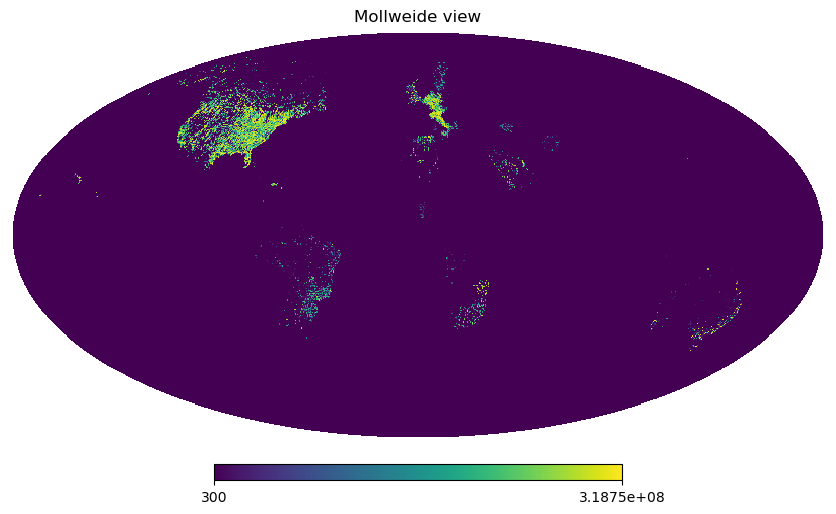

In [7]:
Tx_pow_128=np.zeros(hp.nside2npix(128))
for index,p in enumerate(pixel_128):
    Tx_pow_128[p]+=(power_128[index])
hp.mollview(Tx_pow_128,flip='geo',min=300,cmap='viridis',norm='hist')
plt.show()

### HEALPix map of HDI

In [8]:
##---------Read the tif file---------##
HDI=tiff.imread('/home/pratush/HDI_STARFIRE.tif')
HDI_array=np.array(HDI)

#----------Define the spherical coordinates----------#
theta1 = np.linspace(np.radians(0), np.radians(180), num=HDI_array.shape[0],endpoint=False)
phi1 = np.linspace(-np.radians(180), np.radians(180), num=HDI_array.shape[1],endpoint=False)

#---------- Set angular resolution----------#
nside = 128

##--------Make empty healpix mask and pixel values vector--------##
HDI_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts1 = np.zeros(hp.nside2npix(nside), dtype=int)


for i in range(len(theta1)):
    for j in range(len(phi1)):
        pixel1 = hp.ang2pix(nside, theta1[i], phi1[j])
        HDI_map[pixel1] += HDI_array[i, j]
        pixel_counts1[pixel1] += 1

#--------Average value of each pixel--------#
HDI_map[pixel_counts1>0] /= pixel_counts1[pixel_counts1>0 ]


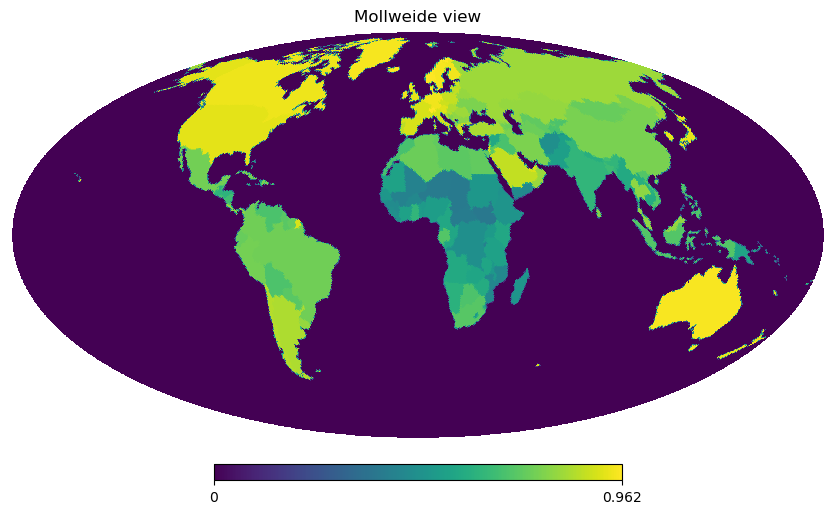

In [9]:
hp.mollview(HDI_map, cmap="viridis", xsize=3000, flip="geo", min=0)
plt.show()

In [10]:
#the raster map above was created using 'rasterize' function in QGIS software. The original map was a vector 
#shapefile which is already georeferenced. 

### Color coded plot

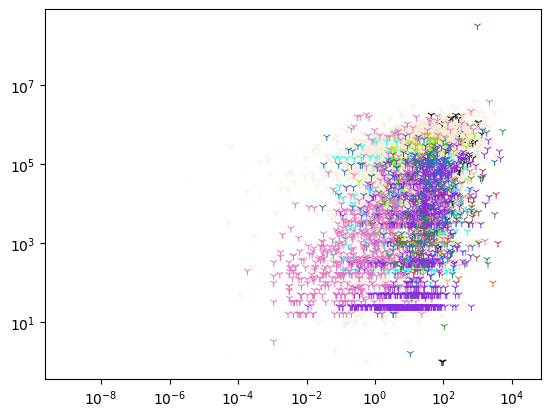

In [11]:
import matplotlib.colors as mcolors
x_=healpix_map

file_paths = csv_files

selected_indices_list = []
color = []

# List of colors and CSV file names
colors =list(mcolors.TABLEAU_COLORS.keys()) + list(mcolors.CSS4_COLORS.keys())
csv_file_names = [file_path.split('/')[-1] for file_path in file_paths]

for file_path in file_paths:
    df = pd.read_csv(file_path)
    lon = df['Longitude in degrees'].to_numpy()
    lat = df['Latitude in degrees'].to_numpy()
    # Remove NaN values from lat_128
    lat = lat[~np.isnan(lat)]

    # Remove NaN values from lon_128
    lon = lon[~np.isnan(lon)]

    selected_indices = hp.ang2pix(128, lon, lat, lonlat=True)
    selected_indices_list.append(selected_indices)

# Loop through the pixels in x_
for pix, _ in enumerate(x_):
    for i, selected_indices in enumerate(selected_indices_list):
        if pix in selected_indices:
            color.append(colors[i])
            break
    else:
        color.append('w')

# Create the scatter plot
plt.scatter(x_, Tx_pow_128, marker='1', linewidths=0.7, c=color)
plt.xscale('log')
plt.yscale('log')

# Create a legend with color and CSV file name mapping
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=csv_file_names[i], markerfacecolor=colors[i], markersize=10) for i in range(len(csv_file_names))]
# plt.legend(handles=legend_elements, title="CSV Files")

plt.show()


In [12]:
#find median pow of each country#
#find std devs of each datapoint with median as central tendency#
#same exercise for pop dens as well#
#find corr between std devs and HDI as error bars#


### NSide 128 map of FMSCAN worldwide Tx map (probably binary)

In [13]:
### this map is probably of no use since it doesnt have any metadata associated with it ##

##Read the tif file##
FM = tiff.imread('/home/pratush/hires_fmscan.tif')
FM_array = np.array(FM)
# Define the spherical coordinates#
theta2 = np.linspace(np.radians(0), np.radians(180), num=FM_array.shape[0],endpoint=False)
phi2 = np.linspace(-np.radians(180), np.radians(180), num=FM_array.shape[1],endpoint=False)

# Set angular resolution#
nside = 128

## Make empty healpix mask and pixel values vector##
FMSCAN_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts2 = np.zeros(hp.nside2npix(nside), dtype=int)
for i in range(len(theta2)):
    for j in range(len(phi2)):
        pixel2 = hp.ang2pix(nside, theta2[i], phi2[j])
        FMSCAN_map[pixel2] += FM_array[i, j]
        pixel_counts2[pixel2] += 1

# Average value of each pixel#
FMSCAN_map[pixel_counts2>0] /= pixel_counts2[pixel_counts2>0 ]



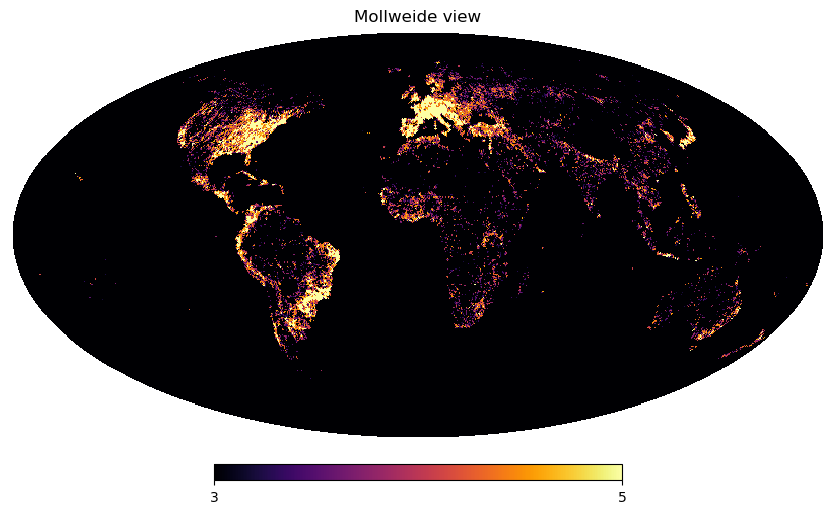

In [14]:
hp.mollview(FMSCAN_map,flip='geo',cmap='inferno',min=3,norm='hist')

In [15]:
reqang=hp.nside2pixarea(128, degrees = True)  
area=(reqang*510e6)/(360*180)
print(f"area of each pixel in sq km is\n",area)

area of each pixel in sq km is
 1651.3879593275271


In [16]:
#global avg pop dens is 62 per sq km, so for area of 1652 sq km, pop dens would be ~0.03#
#hence disregard values lesser than 1e-2#
#no need to filter out ocean values since indices are selected based on pixels that have Tx data in them#

healpix_map[healpix_map<1e-2]=0


## trends between HDI and st. dev of Tx power about median Tx power


In [17]:
def std_median(data):
    median = np.median(data)
    abs_deviations = np.abs(data - median)
    squared_deviations = abs_deviations ** 2
    mean_squared_deviations = np.mean(squared_deviations)
    std_deviation = np.sqrt(mean_squared_deviations)
    return std_deviation




In [18]:
# std_med=[]
# HDIval=[]
# meddata=[]
# popdens=[]
# for file in csv_files:
#     tempdf=pd.read_csv(file)
#     data=tempdf['EIRP'].to_numpy()
#     meddata.append(np.median(data))
#     std_med.append(std_median(data))
#     temphdi=tempdf['HDI'][0]
#     HDIval.append(temphdi)
#     popdens.append(tempdf['popdens'][0])

## HDI versus Country wise parameters plot



In [19]:
# plt.scatter(HDIval,meddata,marker='1')
# # plt.errorbar(HDIval,meddata,yerr=std_med,fmt='none', marker='1')
# plt.xlabel('HDI')
# plt.ylabel('Median Tx power')
# # plt.ylim(bottom=0)
# # plt.xlim(left=0.85)
# # plt.yscale('log')
# # plt.xscale('log')
# plt.show()

In [20]:
# plt.scatter(popdens,meddata,marker='1')
# # plt.errorbar(HDIval,meddata,yerr=std_med,fmt='none', marker='1')
# plt.xlabel('HDI')
# plt.ylabel('Median Tx power')
# # plt.ylim(bottom=0)
# # plt.xlim(left=0.85)
# plt.yscale('log')
# plt.xscale('log')
# plt.show()

## Trying country area as a factor

In [21]:
##Read the tif file##
Area = tiff.imread('/home/pratush/Downloads/country_arearaster.tif')
Area_array = np.array(Area)
# Define the spherical coordinates#
theta3 = np.linspace(np.radians(0), np.radians(180), num=Area_array.shape[0],endpoint=False)
phi3 = np.linspace(-np.radians(180), np.radians(180), num=Area_array.shape[1],endpoint=False)

# Set angular resolution#
nside = 128

## Make empty healpix mask and pixel values vector##
Area_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts3 = np.zeros(hp.nside2npix(nside), dtype=int)
for i in range(len(theta3)):
    for j in range(len(phi3)):
        pixel3 = hp.ang2pix(nside, theta3[i], phi3[j])
        Area_map[pixel3] += Area_array[i, j]
        pixel_counts3[pixel3] += 1

# Average value of each pixel#
Area_map[pixel_counts3>0] /= pixel_counts3[pixel_counts3>0 ]



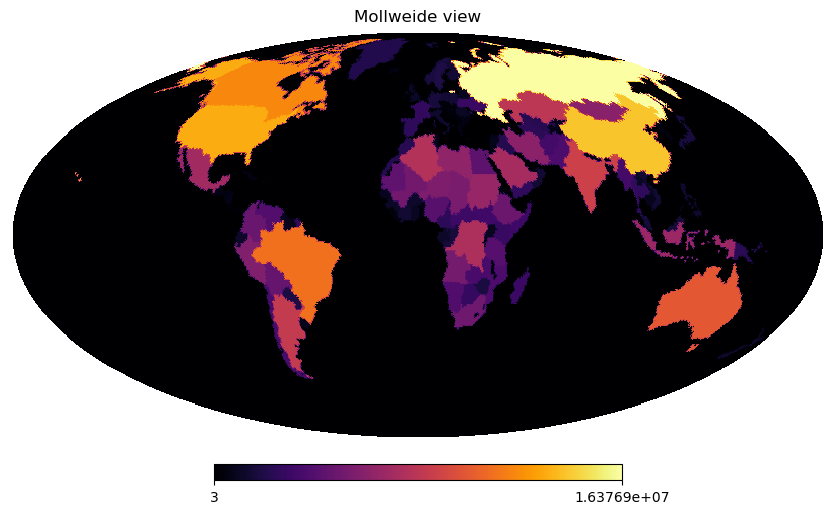

In [22]:
hp.mollview(Area_map,flip='geo',cmap='inferno',min=3,norm='hist')

## mask water pixels and plot

In [23]:
land_pix=(healpix_map>0)&(Tx_pow_128>0)

In [24]:
healpix_map=healpix_map[land_pix]
HDI_map=HDI_map[land_pix]
Tx_pow_128=Tx_pow_128[land_pix]
Area_map=Area_map[land_pix]

In [25]:
Area_map/=np.max(Area_map)

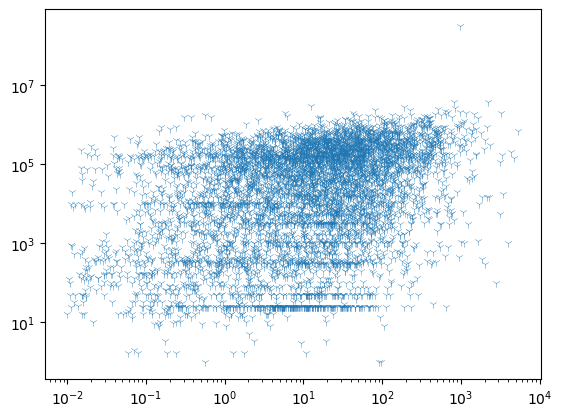

In [26]:
x_final=(healpix_map)
y_final=Tx_pow_128
plt.scatter(x_final,y_final,marker='1',linewidths=0.3)
plt.xscale('log')
plt.yscale('log')

## Plotting histograms of worldwide Tx

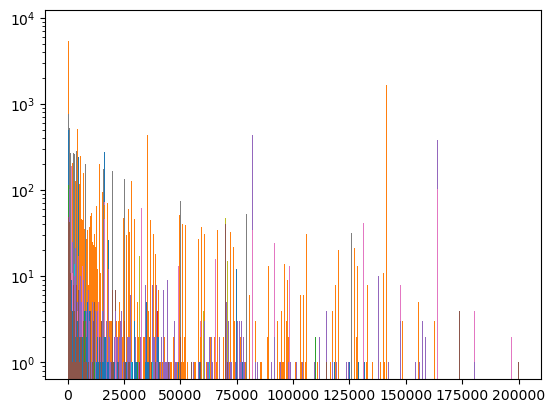

In [28]:
for file in csv_files:
    tempdf=pd.read_csv(file)
    data=tempdf['EIRP'].to_numpy()
    plt.hist(data,stacked=True,bins=np.linspace(0,2e5,1000))
plt.yscale('log')

plt.show()